<a href="https://colab.research.google.com/github/Anais-GD/AEI-Trabajo10-CropYield-ML/blob/main/scripts/s2_analisis_exploratorio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
##############################################################################################
#
#   Nombre script :   s2_analisis_exploratorio (UTF-8)
#
#   Trabajo :      "Estimación de rendimiento de cultivos con Machine Learning."
#   Autores :       K.Bastidas (kabasicg@gmail.com) y A. Galvañ (galvanyanadom@gmail.com)
#   Fecha  :        25.02.2026
#   Objetivo :      Análisis exploratorio de las variables de entrada por cultivo.
#
##############################################################################################

In [34]:
#-----------------------
# Paquetes necesarios
#-----------------------
import importlib, subprocess, sys

def ipak(packages):
    for pkg in packages:
        if ":" in pkg:
            install_name, import_name = pkg.split(":")
        else:
            install_name = import_name = pkg
        if not importlib.util.find_spec(import_name):
            subprocess.check_call([sys.executable, "-m", "pip", "install", install_name],
                                  stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

ipak(["pandas", "numpy", "matplotlib", "seaborn",
      "matplotlib-scalebar:matplotlib_scalebar",
      "scipy", "scikit-learn:sklearn", "requests",
      "geopandas", "pygris"])

import warnings
warnings.filterwarnings('ignore')

import os, io, zipfile, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from pygris import states
import matplotlib.patches as mpatches

In [46]:
#------------------------------
# Carga de datos desde Zenodo
#------------------------------
zip_url = "https://zenodo.org/records/7602711/files/CONUS_CropYield_Data.zip?download=1"
zipfile.ZipFile(io.BytesIO(requests.get(zip_url).content)).extractall("data")

directory_path = next(
    os.path.join("data", d) for d in os.listdir("data")
    if os.path.isdir(os.path.join("data", d))
)

crops = ["wheat", "corn", "soybean"]
dataframes = {}

for crop in crops:
    crop_dir = os.path.join(directory_path, crop)

    EVI   = pd.read_csv(os.path.join(crop_dir, f"EVI_{crop}.csv"))
    PRCP  = pd.read_csv(os.path.join(crop_dir, f"PRCP_{crop}.csv"))
    SM    = pd.read_csv(os.path.join(crop_dir, f"SM_{crop}.csv"))
    TMAX  = pd.read_csv(os.path.join(crop_dir, f"TMAX_{crop}.csv"))
    VOD   = pd.read_csv(os.path.join(crop_dir, f"VOD_{crop}.csv"))
    ID    = pd.read_csv(os.path.join(crop_dir, f"{crop}_id.csv"))
    YIELD = pd.read_csv(os.path.join(crop_dir, f"yield_{crop}.csv"))
    YEAR  = pd.read_csv(os.path.join(crop_dir, f"yyyy_{crop}.csv"),
                        header=None, names=["year"])

    df = pd.concat([ID, YEAR, YIELD, EVI, PRCP, SM, TMAX, VOD], axis=1)

    # soybean tiene columna 'soy' en vez de 'yield'
    yield_col = 'soy' if 'soy' in df.columns else crop
    df = df.rename(columns={yield_col: 'yield', f"{crop}_id": "id"})
    df["crop"] = crop

    dataframes[crop] = df

#--------------------------------------
# Cargamos los shapefiles por cultivo
#--------------------------------------
shp_dir = os.path.join(directory_path, "shapefiles")

shp_names = {"wheat": "CONUS_wheat.shp", "corn": "CONUS_corn.shp", "soybean": "CONUS_soy.shp"}

gdfs = {}
for crop in crops:
    gdf = gpd.read_file(os.path.join(shp_dir, shp_names[crop]))
    if gdf.crs is None or gdf.crs.to_epsg() != 4326:
        gdf = gdf.set_crs(epsg=4326, allow_override=True)
    if 'ID' not in gdf.columns:
        poly_csv = os.path.join(directory_path, crop, f"polygons_{crop}.csv")
        if os.path.isfile(poly_csv):
            poly_df = pd.read_csv(poly_csv)
            poly_df.columns = [c.strip() for c in poly_df.columns]
            gdf = gdf.reset_index(drop=True)
            gdf['ID'] = poly_df.iloc[:, 0].values
        else:
            gdf['ID'] = gdf.index.values
    gdfs[crop] = gdf
    print(f"{crop}: {len(gdf)} polígonos | CRS: {gdf.crs}")

# Fondo USA
us = states(cb=True, resolution="20m", year=2020)
us = us.to_crs(epsg=4326)
us_conus = us[~us["STUSPS"].isin(["AK", "HI", "PR", "VI", "GU", "MP", "AS"])]


wheat: 259 polígonos | CRS: EPSG:4326
corn: 436 polígonos | CRS: EPSG:4326
soybean: 515 polígonos | CRS: EPSG:4326


In [42]:
#--------------------------------------------------
# configuración de la estética de los gráficos
#--------------------------------------------------

plt.rcParams['font.sans-serif'] = ['Century Gothic', 'URW Gothic', 'Lato',
                                   'DejaVu Sans', 'sans-serif']
plt.rcParams['font.family']      = 'sans-serif'
plt.rcParams['axes.facecolor']   = 'white'
plt.rcParams['figure.facecolor'] = 'white'

# Una paleta por cultivo
color_palettes = {
    'wheat': {
        'TMAX' : "#e9c46a",
        'PRCP' : "#f4a261",
        'VOD'  : "#f3722c",
        'EVI'  : "#264653",
        'SM'   : "#2a9d8f",
        'Yield': "#a7c957"
    },
    'corn': {
        'TMAX' : "#ffcdb2",
        'PRCP' : "#ffb4a2",
        'VOD'  : "#f94144",
        'EVI'  : "#bc4749",
        'SM'   : "#e5989b",
        'Yield': "#9a031e"
    },
    'soybean': {
        'TMAX' : "#c77dff",
        'PRCP' : "#9d4edd",
        'VOD'  : "#7b2fff",
        'EVI'  : "#4361ee",
        'SM'   : "#4cc9f0",
        'Yield': "#0077b6"
    }
}
crop_labels = {"wheat": "Trigo", "corn": "Maíz", "soybean": "Soja"}
vars_order   = ['TMAX', 'PRCP', 'VOD', 'EVI', 'SM', 'Yield']

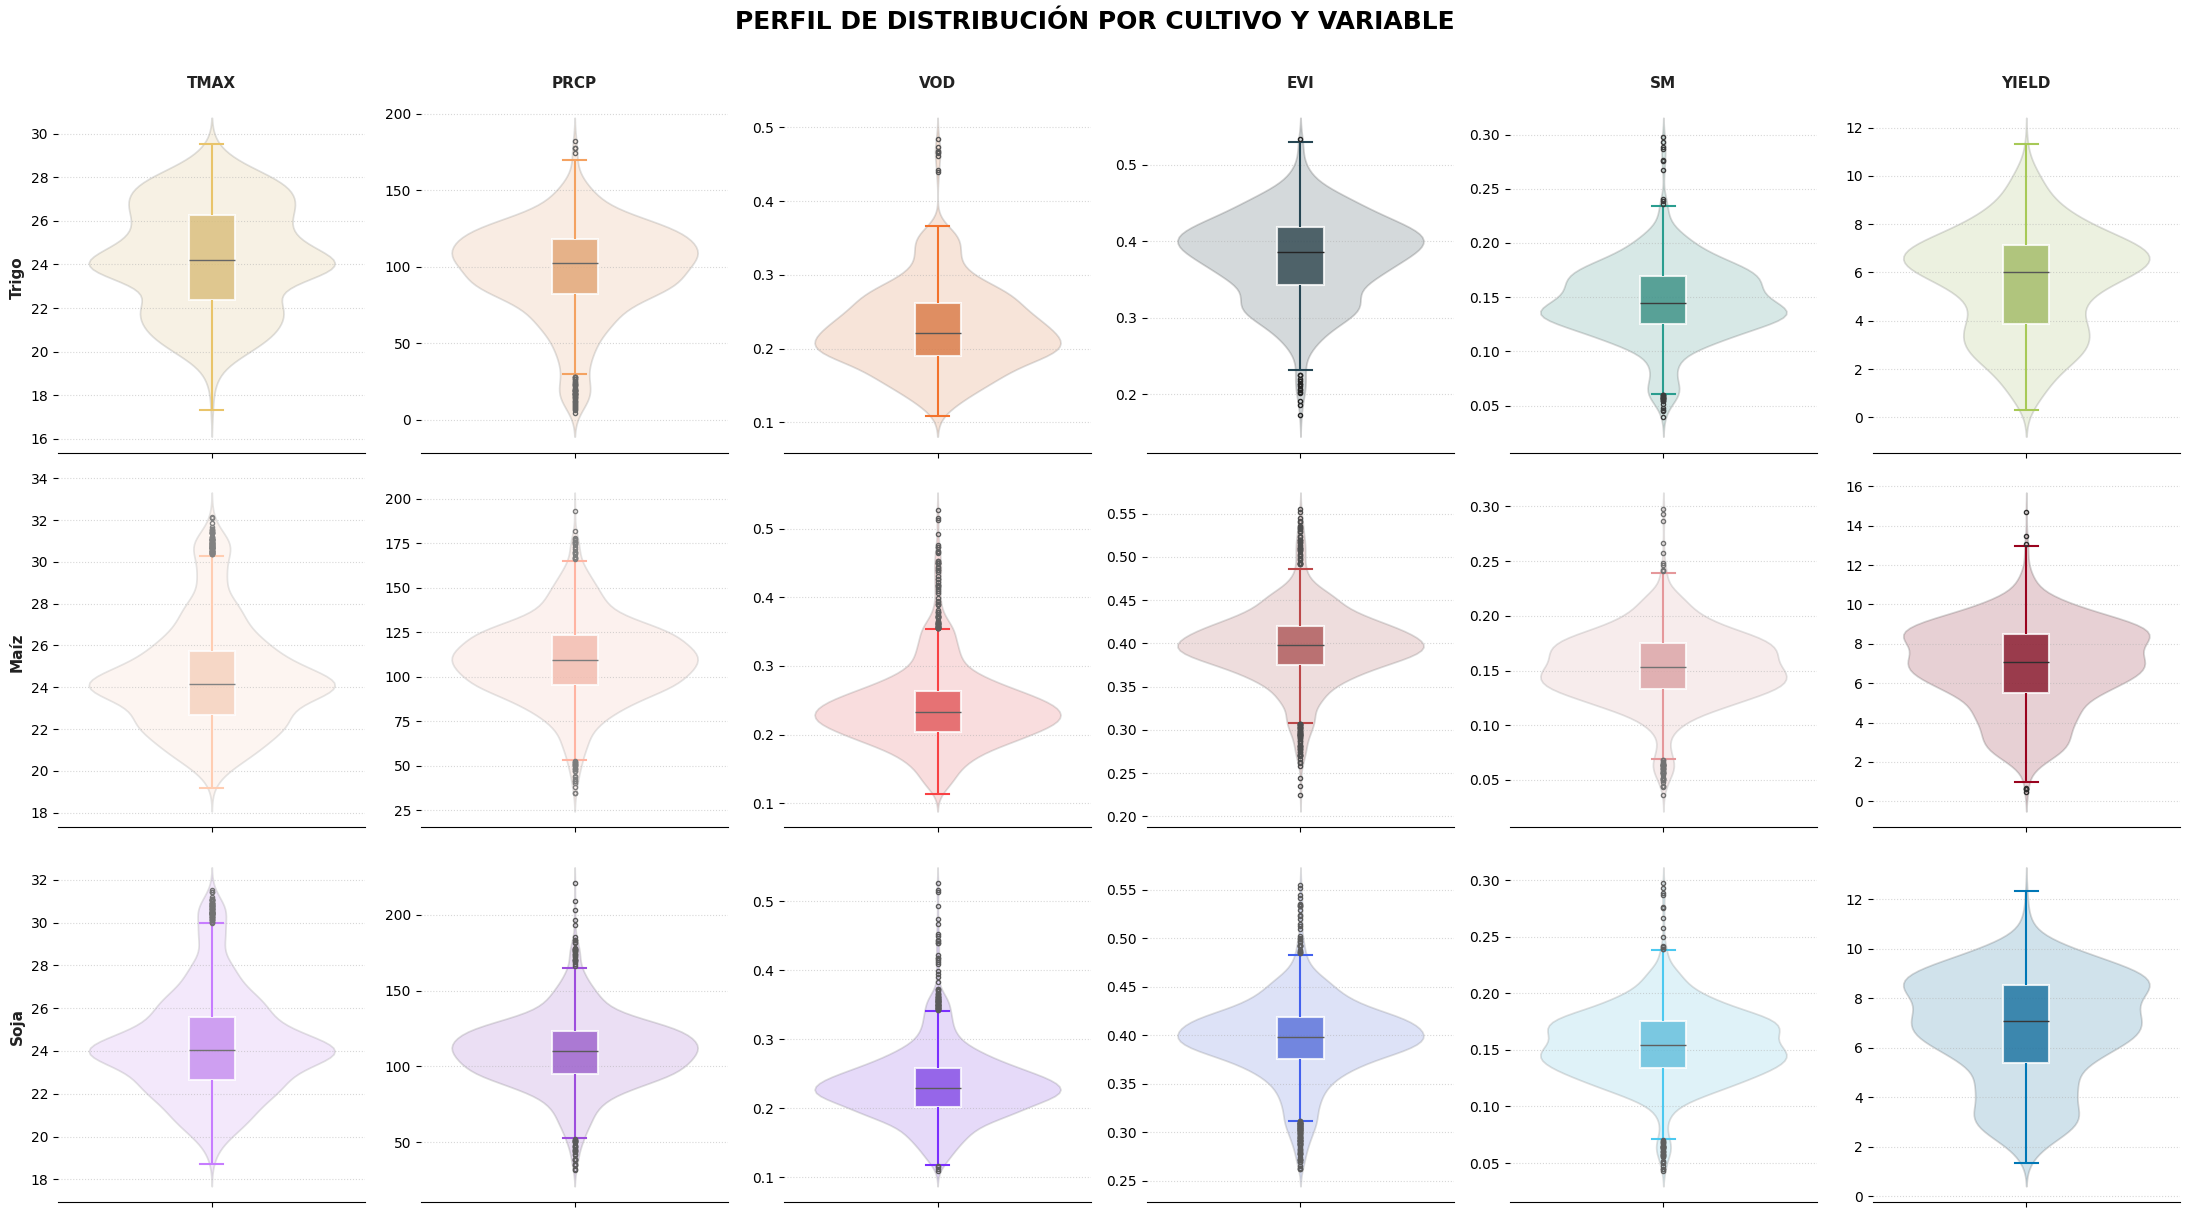

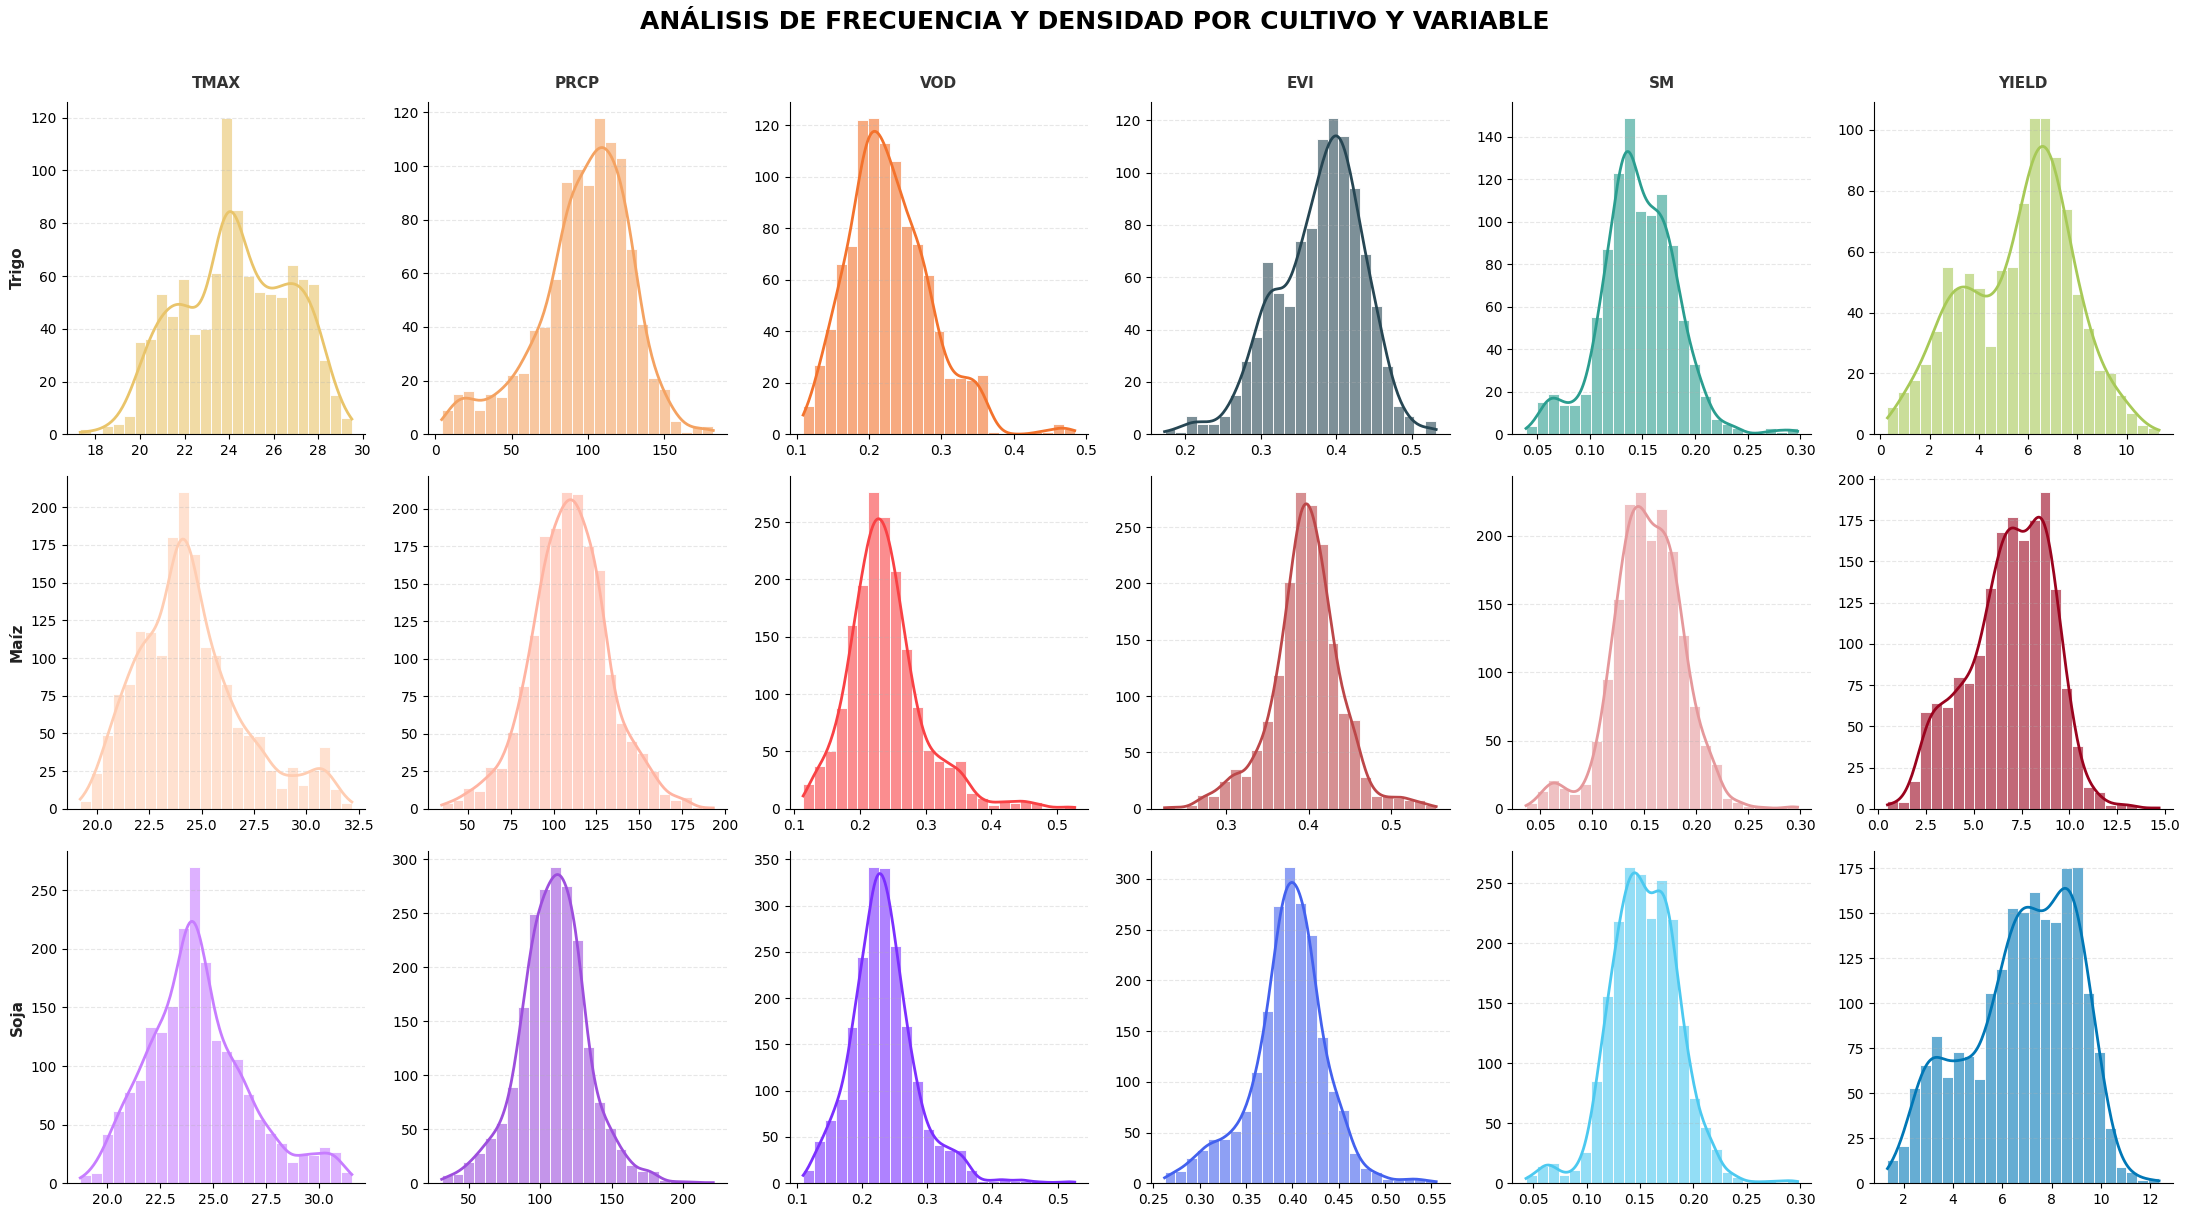

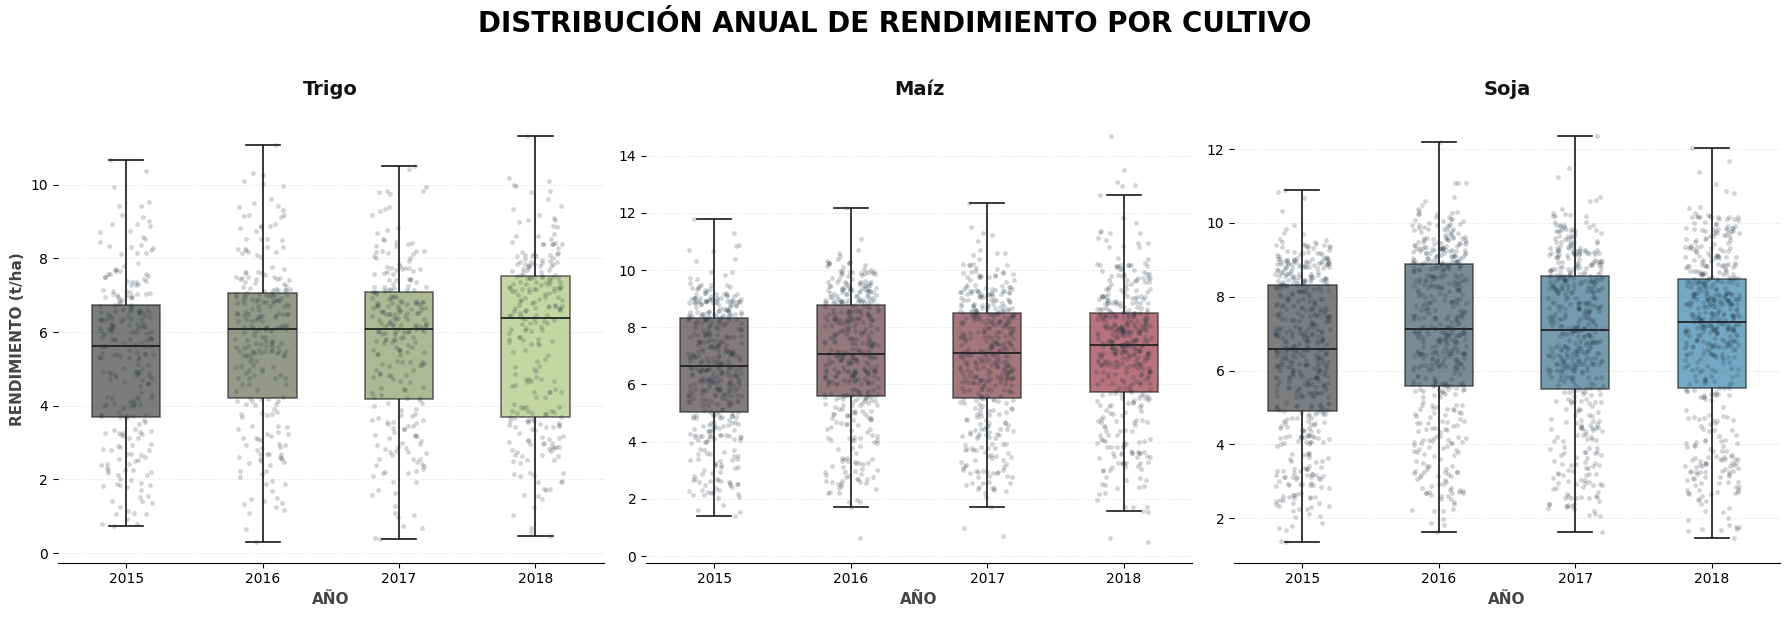

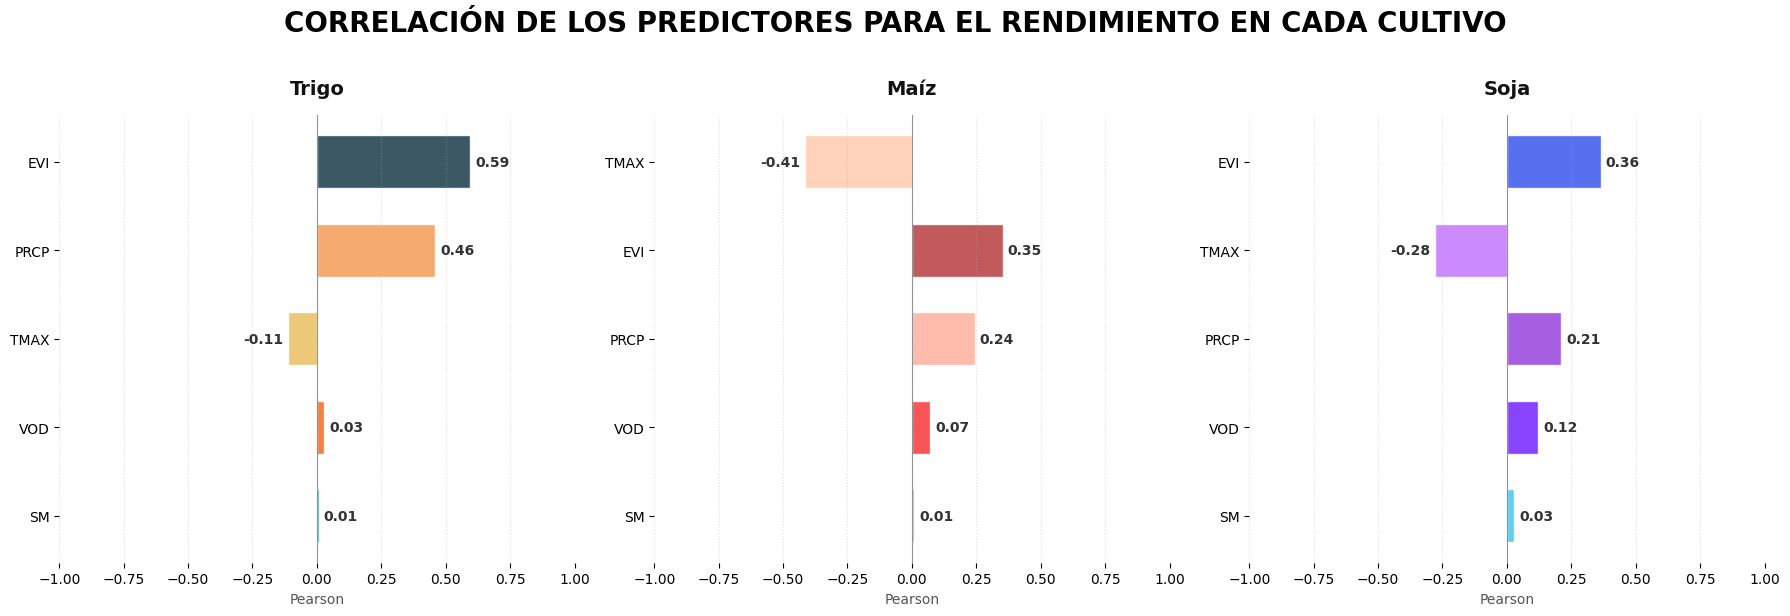

In [45]:
#-------------------------------------------
# Análisis exploratorio por cultivo
#-------------------------------------------

# Precalculamos summary_vars para cada cultivo
all_summary = {}
for crop in crops:
    df = dataframes[crop]
    # La columna yield puede llamarse con el nombre del cultivo
    yield_col = 'yield' if 'yield' in df.columns else crop
    tmax_mean    = df.filter(like='TMAX').mean(axis=1).groupby([df['id'], df['year']]).mean()
    prcp_mean    = df.filter(like='PRCP').mean(axis=1).groupby([df['id'], df['year']]).mean()
    vod_mean     = df.filter(like='VOD').mean(axis=1).groupby([df['id'], df['year']]).mean()
    evi_mean     = df.filter(like='EVI').mean(axis=1).groupby([df['id'], df['year']]).mean()
    sm_mean      = df.filter(like='SM').mean(axis=1).groupby([df['id'], df['year']]).mean()
    yield_series = df.set_index(['id', 'year'])[yield_col]
    all_summary[crop] = {
        'TMAX': tmax_mean, 'PRCP': prcp_mean, 'VOD': vod_mean,
        'EVI' : evi_mean,  'SM'  : sm_mean,   'Yield': yield_series
    }

#------------------
# Violin + Boxplot
#------------------
fig, axes = plt.subplots(3, 6, figsize=(22, 12))
fig.patch.set_facecolor('white')

for row, crop in enumerate(crops):
    for col, var_name in enumerate(vars_order):
        ax     = axes[row, col]
        series = all_summary[crop][var_name].dropna()
        color  = color_palettes[crop][var_name]
        sns.violinplot(y=series, ax=ax, color=color, inner=None, alpha=0.2)
        sns.boxplot(y=series, ax=ax, color=color, width=0.15,
                    boxprops=dict(alpha=0.8, edgecolor='white', linewidth=1.5),
                    whiskerprops=dict(color=color, linewidth=1.5),
                    capprops=dict(color=color, linewidth=1.5), fliersize=3)
        if row == 0:
            ax.set_title(var_name.upper(), fontsize=11, fontweight='bold',
                         color='#222222', pad=10)
        if col == 0:
            ax.set_ylabel(crop_labels[crop], fontsize=11, fontweight='bold',
                          color='#222222')
        else:
            ax.set_ylabel('')
        ax.set_xlabel('')
        ax.grid(axis='y', linestyle=':', alpha=0.5)
        sns.despine(ax=ax, left=True)

plt.suptitle('PERFIL DE DISTRIBUCIÓN POR CULTIVO Y VARIABLE', fontsize=18,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('distribution_all.png', dpi=150, bbox_inches='tight')
plt.show()

#------------------
# Histogramas
#------------------
fig, axes = plt.subplots(3, 6, figsize=(22, 12))
fig.patch.set_facecolor('white')

for row, crop in enumerate(crops):
    for col, var_name in enumerate(vars_order):
        ax     = axes[row, col]
        series = all_summary[crop][var_name].dropna()
        color  = color_palettes[crop][var_name]
        sns.histplot(series, bins=25, kde=True, ax=ax, color=color,
                     edgecolor='white', alpha=0.6, line_kws={'linewidth': 2})
        if row == 0:
            ax.set_title(var_name.upper(), fontsize=11, fontweight='bold',
                         color='#333333', pad=10)
        if col == 0:
            ax.set_ylabel(crop_labels[crop], fontsize=11, fontweight='bold',
                          color='#222222')
        else:
            ax.set_ylabel('')
        ax.set_xlabel('')
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        sns.despine(ax=ax)

plt.suptitle('ANÁLISIS DE FRECUENCIA Y DENSIDAD POR CULTIVO Y VARIABLE', fontsize=18,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('histograms_all.png', dpi=150, bbox_inches='tight')
plt.show()

#--------------------------------------------
# Productividad por año
#--------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, crop in enumerate(crops):
    ax            = axes[idx]
    yield_series  = all_summary[crop]['Yield']
    yield_by_year = yield_series.reset_index(name='yield')
    color         = color_palettes[crop]['Yield']
    sns.boxplot(x='year', y='yield', data=yield_by_year, hue='year',
                color=color, width=0.5, linewidth=1.2,
                fliersize=0, boxprops=dict(alpha=0.6), legend=False, ax=ax)
    sns.stripplot(x='year', y='yield', data=yield_by_year,
                  color='#21313E', jitter=0.2, size=3.5, alpha=0.2, ax=ax)
    ax.set_title(crop_labels[crop], fontsize=14, fontweight='bold',
                 color='#111111', pad=15)
    ax.set_xlabel('AÑO', fontsize=11, fontweight='bold', color='#444444')
    ax.set_ylabel('RENDIMIENTO (t/ha)' if idx == 0 else '',
                  fontsize=11, fontweight='bold', color='#444444')
    ax.grid(axis='y', linestyle=':', alpha=0.4)
    sns.despine(left=True, bottom=False)
plt.suptitle('DISTRIBUCIÓN ANUAL DE RENDIMIENTO POR CULTIVO', fontsize=20,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('yield_by_year_all.png', dpi=150, bbox_inches='tight')
plt.show()

#--------------------------------------------------
# Correlación de Pearson para la producción
#--------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, crop in enumerate(crops):
    ax      = axes[idx]
    summary = all_summary[crop]
    correlation_data = pd.DataFrame({
        'EVI' : summary['EVI'],  'PRCP': summary['PRCP'],
        'TMAX': summary['TMAX'], 'SM'  : summary['SM'],
        'VOD' : summary['VOD'],  'Yield': summary['Yield']
    })
    corr_matrix       = correlation_data.corr(method='pearson')
    yield_corr        = corr_matrix['Yield'].drop('Yield')
    yield_corr_sorted = yield_corr.reindex(
        yield_corr.abs().sort_values(ascending=True).index)
    bar_colors = [color_palettes[crop][var] for var in yield_corr_sorted.index]
    bars = ax.barh(yield_corr_sorted.index, yield_corr_sorted.values,
                   color=bar_colors, alpha=0.9, edgecolor='white', height=0.6)
    ax.axvline(0, color='#333333', linestyle='-', linewidth=0.8, alpha=0.5)
    for bar in bars:
        width = bar.get_width()
        ax.text(width + (0.02 if width >= 0 else -0.02),
                bar.get_y() + bar.get_height() / 2,
                f'{width:.2f}', va='center',
                ha='left' if width >= 0 else 'right',
                fontsize=10, fontweight='bold', color='#333333')
    ax.set_title(crop_labels[crop], fontsize=14, fontweight='bold',
                 color='#111111', pad=15)
    ax.set_xlabel('Pearson', fontsize=10, color='#555555')
    ax.set_xlim(-1, 1)
    ax.grid(axis='x', linestyle=':', alpha=0.4)
    sns.despine(left=True, bottom=True)
plt.suptitle('CORRELACIÓN DE LOS PREDICTORES PARA EL RENDIMIENTO EN CADA CULTIVO', fontsize=20,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pearson_all.png', dpi=150, bbox_inches='tight')
plt.show()

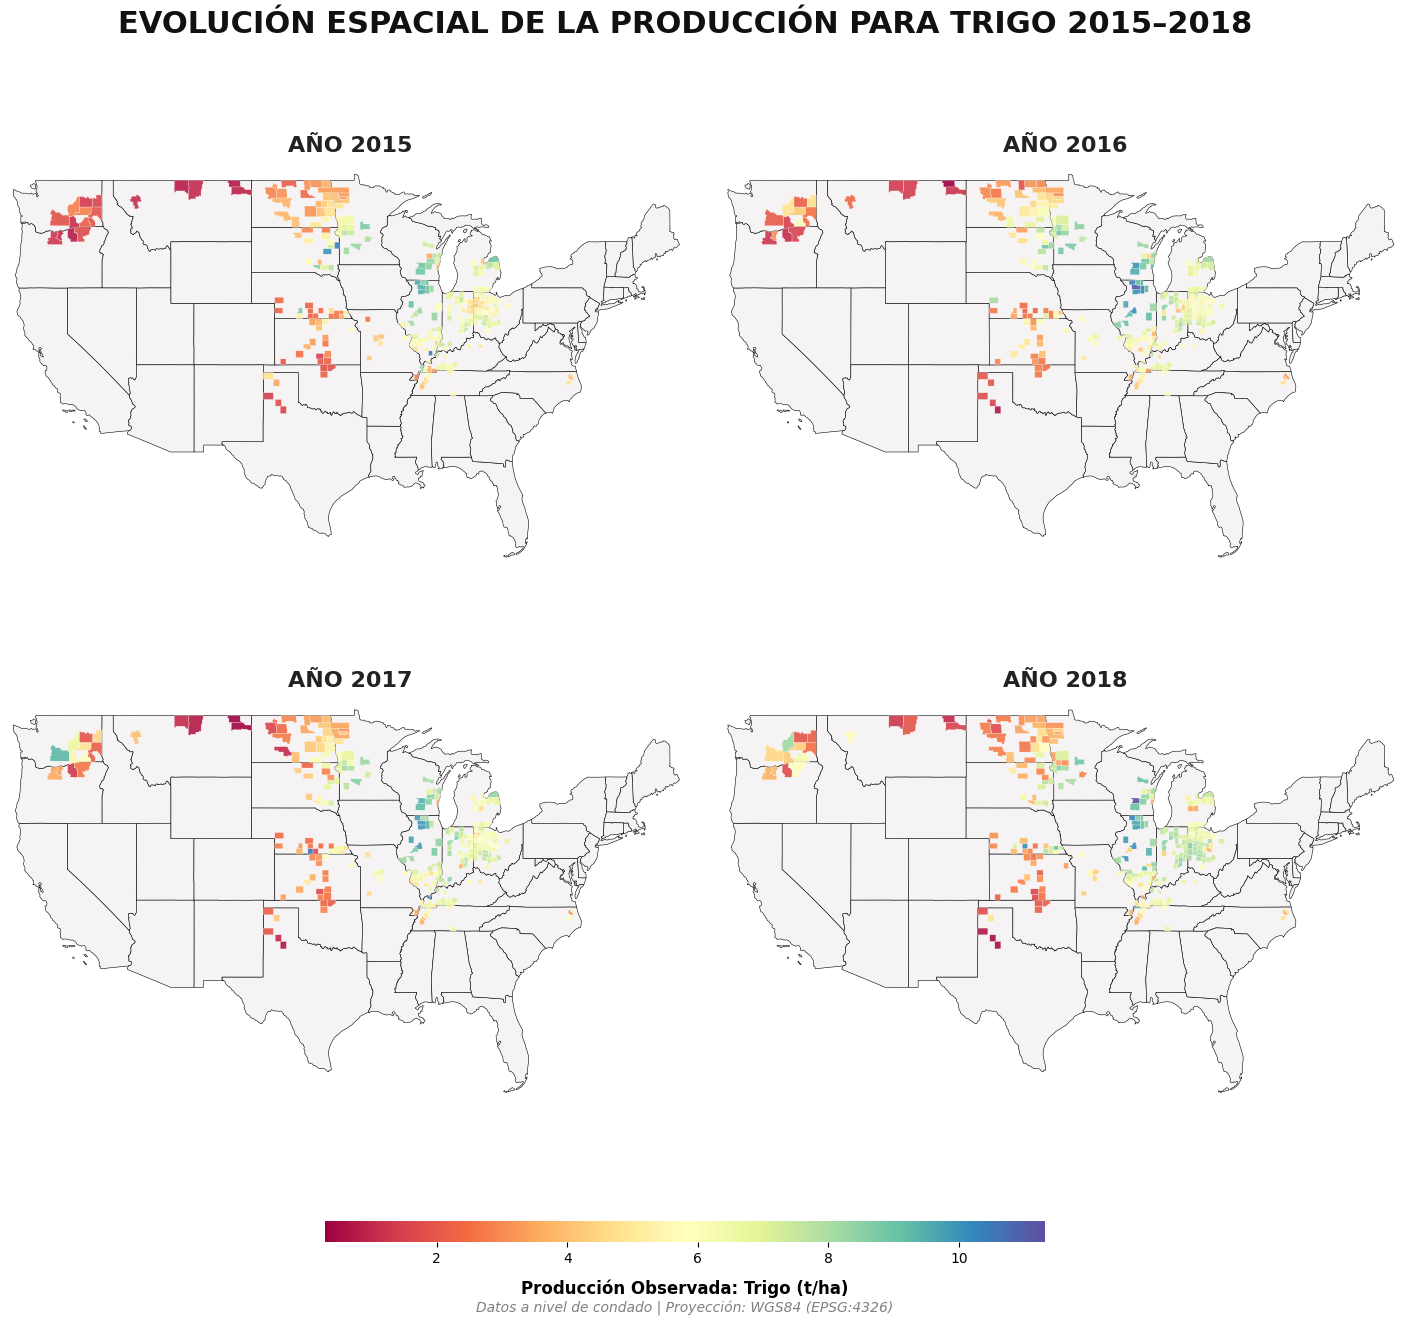

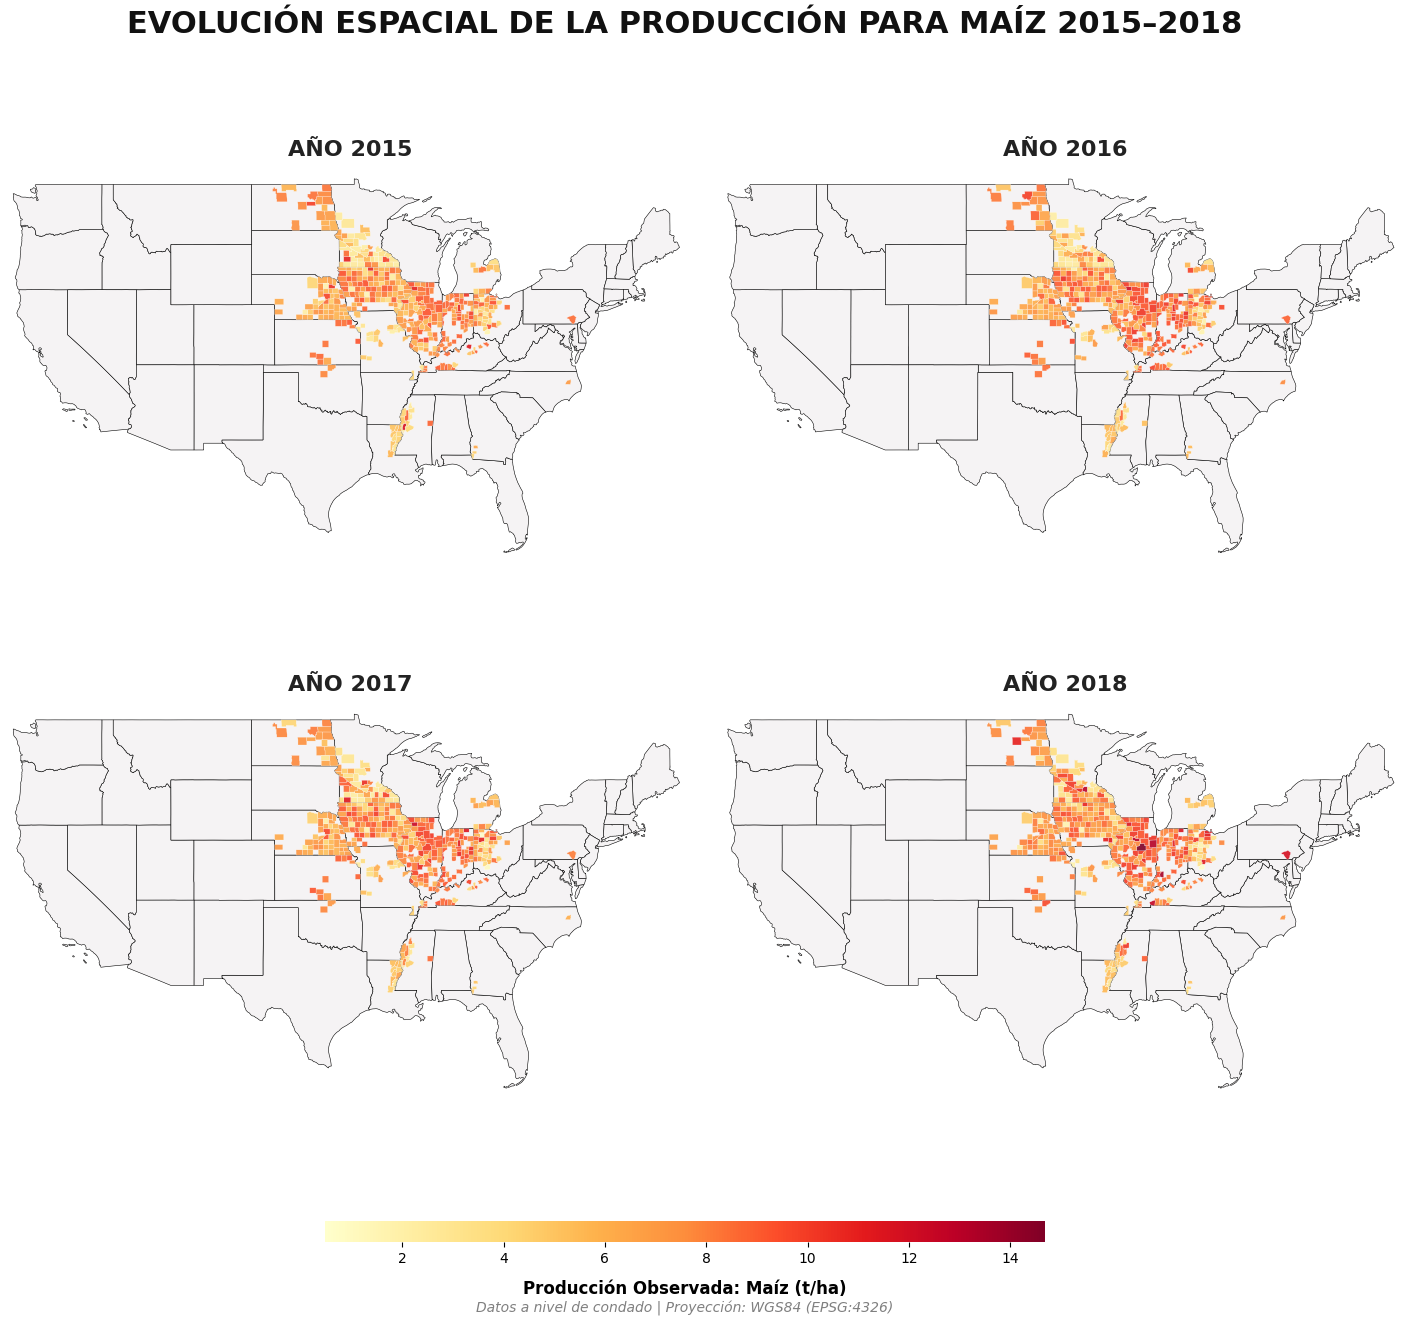

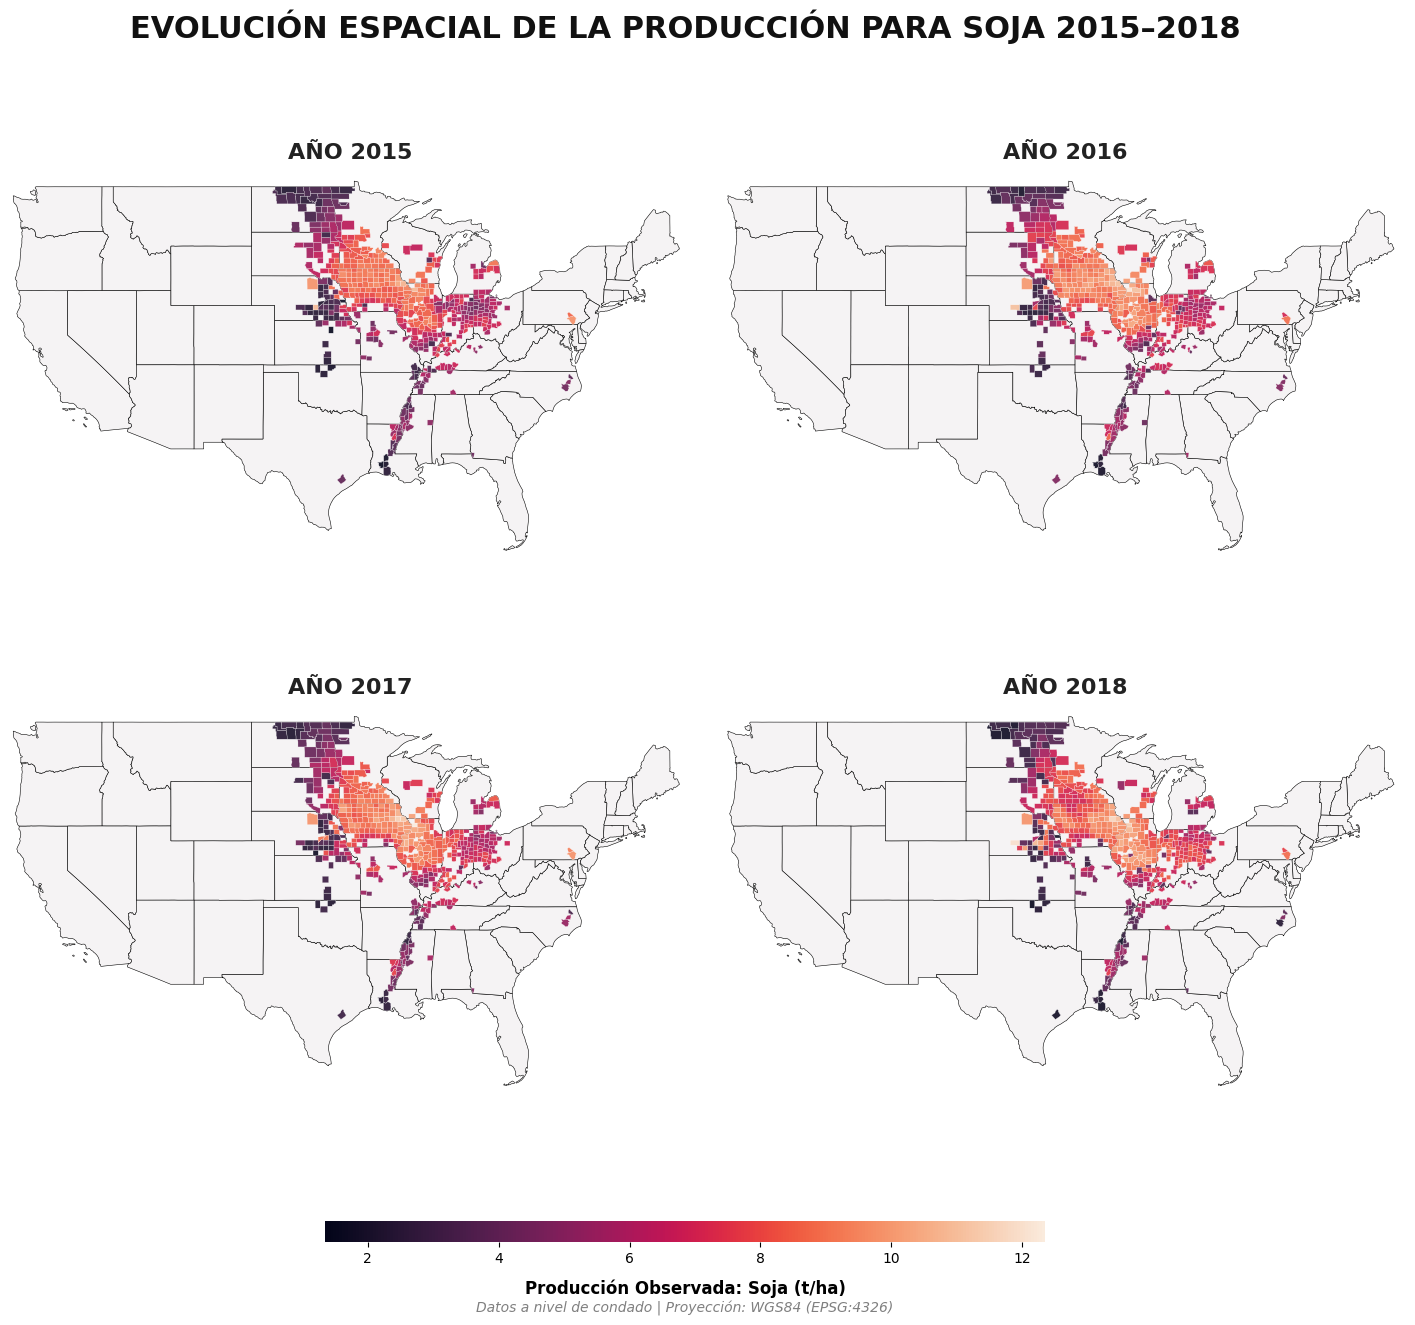

In [58]:
#------------------------------------------------------
# Mapas de producción observada por año y cultivo
#------------------------------------------------------
#Seleccionamos las paletas de color para cada cultivo.
# Esto es totalmente personal, puede ser cualquiera.
cmap_crops = {
    "wheat"  : sns.color_palette("Spectral", as_cmap=True),
    "corn"   : "YlOrRd",
    "soybean": sns.color_palette("rocket", as_cmap=True)
}

#creamos un bucle para que lo procese para cada año, asi reducimos bastante el tamaño del código.
for crop in crops:
    gdf          = gdfs[crop]
    label        = crop_labels[crop]
    yield_data   = all_summary[crop]['Yield'].reset_index(name='yield')
    merged_gdf   = gdf.merge(yield_data, left_on='ID', right_on='id', how='inner')
    merged_gdf   = merged_gdf.to_crs(epsg=4326)
    cmap         = cmap_crops[crop]
    vmin, vmax   = merged_gdf['yield'].min(), merged_gdf['yield'].max()

    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    axes      = axes.flatten()
    fig.patch.set_facecolor('white')

    for i, year in enumerate([2015, 2016, 2017, 2018]):
        ax         = axes[i]
        ax.set_facecolor('white')
        yearly_gdf = merged_gdf[merged_gdf['year'] == year]
        us_conus.plot(ax=ax, color='#f5f3f4', edgecolor='black', linewidth=0.4)
        yearly_gdf.plot(column='yield', ax=ax, cmap=cmap,
                        vmin=vmin, vmax=vmax, alpha=0.9,
                        linewidth=0.2, edgecolor='#ffffff')
        ax.set_xlim(-125, -66)
        ax.set_ylim(24, 50)
        ax.set_title(f'AÑO {year}', fontsize=16, fontweight='bold',
                     color='#222222', pad=10)
        ax.set_axis_off()

    cax     = fig.add_axes([0.3, 0.08, 0.4, 0.015])
    sm_cbar = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    cb      = fig.colorbar(sm_cbar, cax=cax, orientation='horizontal')
    cb.set_label(f'Producción Observada: {label} (t/ha)', fontsize=12,
                 fontweight='bold', labelpad=10)
    cb.outline.set_visible(False)
    plt.suptitle(f'EVOLUCIÓN ESPACIAL DE LA PRODUCCIÓN PARA {label.upper()} 2015–2018',
                 fontsize=22, fontweight='bold', y=0.96, color='#111111')
    plt.figtext(0.5, 0.03, "Datos a nivel de condado | Proyección: WGS84 (EPSG:4326)",
                ha='center', fontsize=10, color='gray', style='italic')
    plt.subplots_adjust(hspace=0.1, wspace=0.05, bottom=0.15)
    plt.savefig(f'observed_production_{crop}.png', dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()
